# 딥러닝 3일차

In [3]:
import keras
import tensorflow as tf
from sklearn.model_selection import train_test_split

In [4]:
# 실행할 때마다 랜덤 값이 동일하게 나오고 싶으면. seed 지정할 것.
# keras.utils.set_random_seed(42)
# tf.random.set_seed(42)
# tf.config.experimental.enable_op_determinism()

In [5]:
# 데이터 불러오기 (학습 데이터만)
(train_input, train_target), _ = keras.datasets.fashion_mnist.load_data()
train_scale = train_input / 255.0

In [6]:
train_scaled, val_scaled, train_target, val_target = train_test_split(train_scale, train_target, test_size=0.2)

In [7]:
train_scaled.shape, val_scaled.shape

((48000, 28, 28), (12000, 28, 28))

In [8]:
# 모델 생성 함수
def model_fn(a_layer=None):
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(28,28)))  # 입력
    model.add(keras.layers.Flatten())  # 평탄화 784
    model.add(keras.layers.Dense(100, activation='relu'))  # 은닉층
    if a_layer:
        model.add(a_layer)     # 매개변수가 있는 경우에만 선택적으로 삽입하는 layer
    model.add(keras.layers.Dense(10, activation='softmax')) # 출력층
    return model

In [9]:
model = model_fn()
model.compile(loss=keras.losses.sparse_categorical_crossentropy, metrics=[keras.metrics.sparse_categorical_accuracy])
# model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy']) # 문자열 입력
history = model.fit(train_scaled, train_target, epochs=5) # 학습 후 history 변환

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.5384 - sparse_categorical_accuracy: 0.8094
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3978 - sparse_categorical_accuracy: 0.8575
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3611 - sparse_categorical_accuracy: 0.8702
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3374 - sparse_categorical_accuracy: 0.8781
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3224 - sparse_categorical_accuracy: 0.8841


In [10]:
history.history

{'loss': [0.5383544564247131,
  0.3977504074573517,
  0.3611273467540741,
  0.33740800619125366,
  0.3223888874053955],
 'sparse_categorical_accuracy': [0.809374988079071,
  0.8575000166893005,
  0.8702083230018616,
  0.8781041502952576,
  0.8841458559036255]}

In [11]:
history.history.keys()

dict_keys(['loss', 'sparse_categorical_accuracy'])

In [12]:
history.history['loss']

[0.5383544564247131,
 0.3977504074573517,
 0.3611273467540741,
 0.33740800619125366,
 0.3223888874053955]

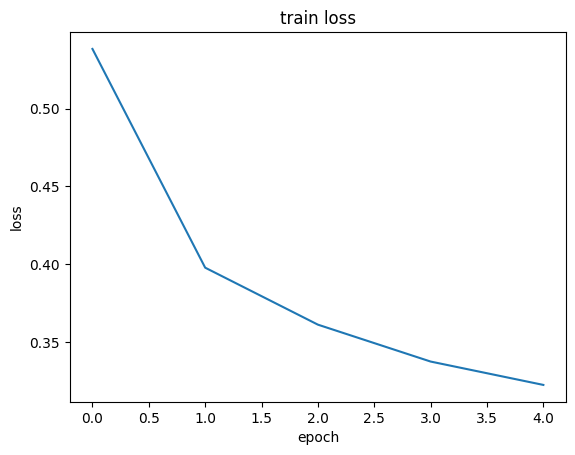

In [13]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('train loss')
plt.show()

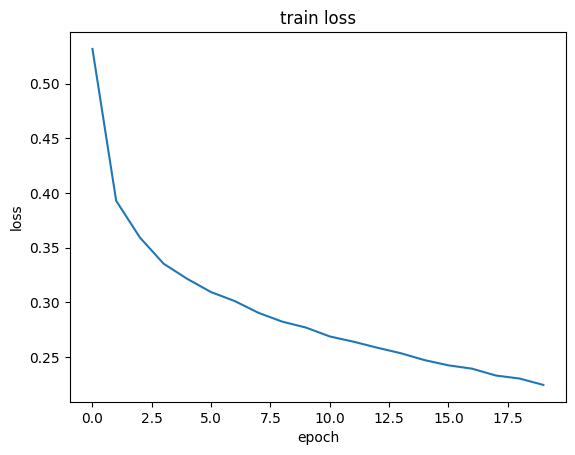

In [16]:
# 20 epoch의 손실 곡선
model = model_fn()
model.compile(loss=keras.losses.sparse_categorical_crossentropy, metrics=[keras.metrics.sparse_categorical_accuracy])
history = model.fit(train_scaled, train_target, epochs=20, verbose=0) # 에폭 20, 출력 없이

plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('train loss')
plt.show()

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.5328 - sparse_categorical_accuracy: 0.8127 - val_loss: 0.4100 - val_sparse_categorical_accuracy: 0.8540
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3924 - sparse_categorical_accuracy: 0.8587 - val_loss: 0.3552 - val_sparse_categorical_accuracy: 0.8742
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3552 - sparse_categorical_accuracy: 0.8708 - val_loss: 0.3590 - val_sparse_categorical_accuracy: 0.8665
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3360 - sparse_categorical_accuracy: 0.8798 - val_loss: 0.3556 - val_sparse_categorical_accuracy: 0.8698
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3205 - sparse_categorical_accuracy: 0.8868 - val_loss: 0.3328 - val_sparse_categorical_accuracy: 0.8832
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3081 - sparse_categorical_accuracy: 0.8897 - val_loss: 0.3397 - val_sparse_categorical_accuracy:

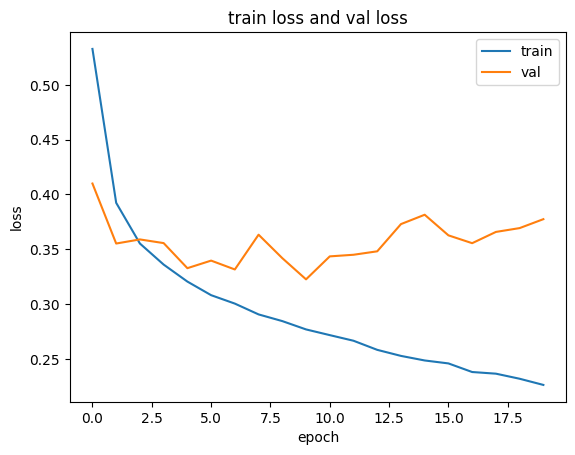

In [18]:
# validation 검증 데이터와 손실(loss) 비교
model = model_fn()
# optimizer : rmrprop
model.compile(loss=keras.losses.sparse_categorical_crossentropy, metrics=[keras.metrics.sparse_categorical_accuracy])
history = model.fit(train_scaled, train_target, epochs=20, # 에폭 20, 출력 없이
                    validation_data=(val_scaled, val_target)) 

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.title('train loss and val loss')
plt.show()

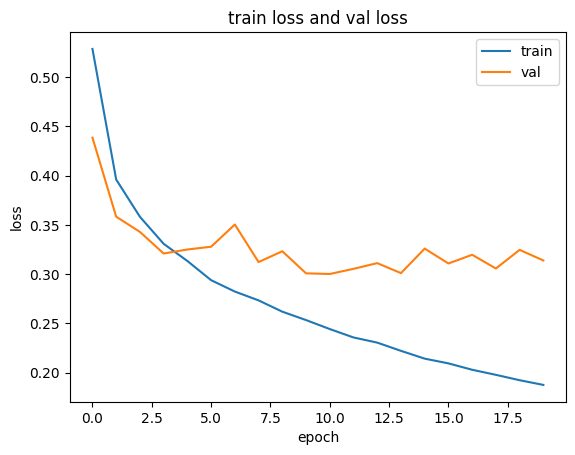

In [19]:
# validation 검증 데이터와 손실(loss) 비교
model = model_fn()
# optimizer : adam
model.compile(optimizer='adam',
            loss=keras.losses.sparse_categorical_crossentropy, 
              metrics=[keras.metrics.sparse_categorical_accuracy])
history = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data=(val_scaled, val_target)) 

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.title('train loss and val loss')
plt.show()

# Dropout

In [22]:
history.history['loss']

[0.18261747062206268,
 0.17946362495422363,
 0.1740899682044983,
 0.17097584903240204,
 0.16677020490169525,
 0.16293102502822876,
 0.1587059050798416,
 0.15633325278759003,
 0.15271441638469696,
 0.14812737703323364,
 0.14652705192565918,
 0.14118298888206482,
 0.14045891165733337,
 0.13783933222293854,
 0.13434816896915436,
 0.13154186308383942,
 0.13091886043548584,
 0.12788814306259155,
 0.12433768063783646,
 0.1226532980799675]

In [21]:
model = model_fn(a_layer=keras.layers.Dropout(0.3))  # 드롭 아웃 층을 추가
model.summary()  # 파라미터 수는 변화가 없음
# 뉴런을 끄는 연산만 하고, 가중치는 그대로이기 때문에, 파라미터 수는 변화가 없다.

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

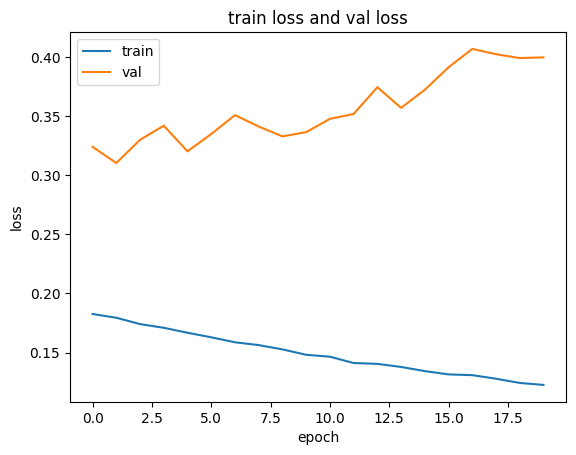

In [20]:
model.compile(optimizer='adam',
              loss=keras.losses.sparse_categorical_crossentropy, 
              metrics=[keras.metrics.sparse_categorical_accuracy])
history = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data=(val_scaled, val_target))

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.title('train loss and val loss')
plt.show()

In [ ]:
history.history['loss']

[0.18454241752624512,
 0.17777925729751587,
 0.17545458674430847,
 0.17206889390945435,
 0.16719365119934082,
 0.1638646274805069,
 0.16068485379219055,
 0.15469282865524292,
 0.1539807766675949,
 0.14958715438842773,
 0.14702565968036652,
 0.14168742299079895,
 0.14068610966205597,
 0.13942022621631622,
 0.1306459903717041,
 0.13354112207889557,
 0.12858600914478302,
 0.12608063220977783,
 0.12255357205867767,
 0.12169276922941208]

In [ ]:
# 드롭아웃 외에도 정규화 방법론이 존재
# L2 정규화 : 수학적 해석 명확, 소규모 데이터셋에서 안정적으로 작동, 랜덤 요소 없음.
# model.add(keras.layers.Dense(100, activation='relu', kernel_regularizer='12'))

# Dropout : 컴퓨터비전(CV)에서 표준.

## 모델 저장